# Sequence/Loss Analysis (Single + Multi Artifacts)


In [5]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from quantum.analyze_problematic_segments import analyze_and_generate_circuits


In [6]:
# Edit directories here if needed
SINGLE_DIR = REPO_ROOT / "artifacts/grover3-3"
print(f"Using artifact dir: {SINGLE_DIR}")


Using artifact dir: /Users/qzydustin/WorkSpace/quantum/artifacts/grover3-3


In [7]:
def format_op(op: dict) -> str:
    op_name = op.get("operation", "?")
    qubits = op.get("qubits", [])
    params = op.get("params", [])
    q_str = ",".join(str(q) for q in qubits)
    if params:
        p_str = ", " + ", ".join(f"{float(p):.4f}" for p in params)
    else:
        p_str = ""
    return f"{op_name}({q_str}{p_str})"


def seq_key(ops: list[dict]) -> str:
    return " -> ".join(format_op(op) for op in ops)


def extract_sequences_from_ops(ops: list[dict], min_len: int = 3, max_len: int = 4) -> list[str]:
    out = []
    n = len(ops)
    for length in range(min_len, min(max_len + 1, n + 1)):
        for i in range(n - length + 1):
            out.append(seq_key(ops[i:i + length]))
    return out


def load_reports(artifact_dir: Path) -> list[dict]:
    files = sorted(artifact_dir.glob("delta_debug_report_*.json"))
    reports = []
    for fp in files:
        with fp.open("r", encoding="utf-8") as f:
            d = json.load(f)
        d["__file"] = str(fp)
        reports.append(d)
    return reports


def _segment_ops(seg: dict) -> list[dict]:
    # problematic segments use "operations"; full-circuit segments_info uses "instructions"
    ops = seg.get("operations")
    if isinstance(ops, list) and ops:
        return ops
    inst = seg.get("instructions")
    if isinstance(inst, list) and inst:
        return [
            {
                "operation": i.get("operation"),
                "qubits": i.get("qubits", []),
                "params": i.get("params", []),
            }
            for i in inst
            if isinstance(i, dict) and i.get("operation")
        ]
    return []


def build_sequence_df(reports: list[dict], artifact_name: str, source: str) -> pd.DataFrame:
    rows = []
    for ridx, report in enumerate(reports):
        analysis = report.get("analysis") or {}

        if source == "caught":
            # Caught counts come from problematic segments in analysis output
            all_segments = analysis.get("segments", [])
            target_ids = set(report.get("problematic_segments", []))
            segments = [s for s in all_segments if s.get("layer_id") in target_ids]
        elif source == "total":
            # Total counts must come from full circuit segmentation
            segments = report.get("segments_info", [])
        else:
            raise ValueError(f"Unknown source: {source}")

        for seg in segments:
            ops = _segment_ops(seg)
            for s in extract_sequences_from_ops(ops, min_len=3, max_len=4):
                rows.append({
                    "artifact": artifact_name,
                    "report_idx": ridx,
                    "report_file": report.get("__file"),
                    "segment_id": seg.get("layer_id"),
                    "sequence": s,
                })

    if not rows:
        return pd.DataFrame(columns=["artifact", "report_idx", "report_file", "segment_id", "sequence"])

    return pd.DataFrame(rows)


def aggregate_sequence_stats(caught_df: pd.DataFrame, total_df: pd.DataFrame, total_reports: int) -> pd.DataFrame:
    if total_df.empty:
        return pd.DataFrame(columns=[
            "sequence",
            "caught_occurrences",
            "total_occurrences",
            "occurrence_capture_rate",
            "reports_caught",
            "report_hit_rate",
        ])

    total_agg = total_df.groupby("sequence", as_index=False).agg(
        total_occurrences=("sequence", "size"),
    )

    if caught_df.empty:
        caught_agg = pd.DataFrame(columns=["sequence", "caught_occurrences", "reports_caught"])
    else:
        caught_agg = caught_df.groupby("sequence", as_index=False).agg(
            caught_occurrences=("sequence", "size"),
            reports_caught=("report_file", lambda s: len(set(s))),
        )

    agg = total_agg.merge(caught_agg, on="sequence", how="left").fillna({
        "caught_occurrences": 0,
        "reports_caught": 0,
    })

    agg["caught_occurrences"] = agg["caught_occurrences"].astype(int)
    agg["reports_caught"] = agg["reports_caught"].astype(int)

    # Example 1: in one report sequence appears 2 times but caught once -> 1/2
    agg["occurrence_capture_rate"] = agg.apply(
        lambda r: (r["caught_occurrences"] / r["total_occurrences"]) if r["total_occurrences"] > 0 else 0.0,
        axis=1,
    )

    # Example 2: appears in 3 of 5 reports -> 3/5
    agg["report_hit_rate"] = agg["reports_caught"] / max(total_reports, 1)

    agg = agg.sort_values(["report_hit_rate", "occurrence_capture_rate", "caught_occurrences"], ascending=False)
    return agg


def plot_top_sequences_by_report_hit_rate(agg_df: pd.DataFrame, total_reports: int, title: str, top_n: int = 15):
    if agg_df.empty:
        print("No sequence data to plot.")
        return

    top = agg_df.sort_values("report_hit_rate", ascending=False).head(top_n).copy().iloc[::-1]

    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    bars = plt.barh(top["sequence"], top["report_hit_rate"], color="teal")
    for bar, num in zip(bars, top["reports_caught"]):
        plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f"{int(num)}/{int(total_reports)}", va="center", fontsize=9)
    plt.xlabel("Report hit rate (reports_caught / total_reports)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_top_sequences_by_occurrence_capture_rate(agg_df: pd.DataFrame, title: str, top_n: int = 15):
    if agg_df.empty:
        print("No sequence data to plot.")
        return

    # Choose top sequences by caught occurrences, then show their caught/total rate.
    # then show their caught/total capture rate.
    top = agg_df.sort_values("caught_occurrences", ascending=False).head(top_n).copy().iloc[::-1]

    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    bars = plt.barh(top["sequence"], top["occurrence_capture_rate"], color="seagreen")
    for bar, num, den in zip(bars, top["caught_occurrences"], top["total_occurrences"]):
        plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f"{int(num)}/{int(den)}", va="center", fontsize=9)
    plt.xlabel("Occurrence capture rate (caught_occurrences / total_occurrences)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def build_operation_hit_series(reports: list[dict], total_reports: int) -> pd.DataFrame:
    """
    Build per-operation hit counts with per-report contribution columns.
    """
    from collections import Counter

    hit_counter = Counter()
    max_op_index = -1
    per_report_hits = []

    for ridx, report in enumerate(reports):
        report_counter = Counter()
        problematic_ids = set(report.get("problematic_segments", []))
        full_segments = report.get("segments_info", [])
        seg_map = {s.get("layer_id"): s for s in full_segments if isinstance(s, dict)}

        for seg in full_segments:
            for inst in seg.get("instructions", []) if isinstance(seg, dict) else []:
                idx = inst.get("index") if isinstance(inst, dict) else None
                if isinstance(idx, int) and idx > max_op_index:
                    max_op_index = idx

        for seg_id in problematic_ids:
            seg = seg_map.get(seg_id)
            if not seg:
                continue
            for inst in seg.get("instructions", []):
                idx = inst.get("index") if isinstance(inst, dict) else None
                if isinstance(idx, int):
                    hit_counter[idx] += 1
                    report_counter[idx] += 1

        per_report_hits.append(report_counter)

    n_ops = max_op_index + 1 if max_op_index >= 0 else 0
    rows = []
    for zero_idx in range(n_ops):
        hits = hit_counter.get(zero_idx, 0)
        row = {
            "op_index": zero_idx + 1,
            "problem_hits": hits,
            "problem_hit_rate": hits / max(total_reports, 1),
        }
        for ridx, report_counter in enumerate(per_report_hits, 1):
            row[f"report_{ridx}"] = report_counter.get(zero_idx, 0) / max(total_reports, 1)
        rows.append(row)

    return pd.DataFrame(rows)


def plot_operation_hit_series(op_df: pd.DataFrame, title: str):
    if op_df.empty:
        print("No operation-level data to plot.")
        return

    max_x = int(op_df["op_index"].max())
    step = max(1, max_x // 20)
    report_cols = [c for c in op_df.columns if c.startswith("report_")]

    plt.figure(figsize=(14, 5))
    bottom = [0.0] * len(op_df)
    cmap = plt.get_cmap("tab10")
    for i, col in enumerate(report_cols):
        vals = op_df[col].tolist()
        plt.bar(op_df["op_index"], vals, bottom=bottom, color=cmap(i % 10), width=0.9, label=col)
        bottom = [b + v for b, v in zip(bottom, vals)]

    plt.xlim(1, max_x)
    plt.xticks(list(range(1, max_x + 1, step)))
    plt.xlabel("Operation Index in Circuit (1..N)")
    plt.ylabel("Problem Hit Rate (stacked by report)")
    plt.title(title)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()


def parse_reports_cell(v):
    import ast
    if isinstance(v, list):
        return [x for x in v if isinstance(x, int)]
    if not isinstance(v, str):
        return []
    try:
        x = ast.literal_eval(v)
    except Exception:
        return []
    return [i for i in x if isinstance(i, int)] if isinstance(x, list) else []


def plot_tvd_vs_report_support(artifact_dir: Path, total_reports: int):
    tvd_csv = artifact_dir / "tvd_summary.csv"
    if not tvd_csv.exists():
        print(f"Missing TVD summary: {tvd_csv}")
        return

    tvd_df = pd.read_csv(tvd_csv)
    tvd_df["tvd_loss"] = pd.to_numeric(tvd_df["tvd_loss"], errors="coerce")
    tvd_df["count"] = pd.to_numeric(tvd_df["count"], errors="coerce").fillna(0)
    tvd_df["reports_len"] = tvd_df["reports"].apply(lambda v: len(parse_reports_cell(v)))
    tvd_df["report_support_rate"] = tvd_df["reports_len"] / max(total_reports, 1)
    tvd_df = tvd_df.sort_values("tvd_loss", ascending=False).reset_index(drop=True)

    fig, ax1 = plt.subplots(figsize=(13, 6))
    x = list(range(len(tvd_df)))
    bars = ax1.bar(x, tvd_df["tvd_loss"], color="tomato", alpha=0.8, label="TVD loss")
    ax1.set_ylabel("TVD loss")
    ax1.set_xlabel("Circuit (sorted by TVD loss)")
    ax1.set_xticks(x)
    ax1.set_xticklabels(tvd_df["circuit"], rotation=40, ha="right")

    for bar, cnt in zip(bars, tvd_df["count"]):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"count={int(cnt)}", ha="center", va="bottom", fontsize=8)

    ax2 = ax1.twinx()
    ax2.plot(x, tvd_df["report_support_rate"], color="navy", marker="o", linewidth=2, label="report support rate")
    ax2.set_ylabel("Report support rate")
    ax2.set_ylim(0, 1.05)

    ax1.grid(axis="y", alpha=0.25, linestyle="--")
    ax1.set_title(f"{artifact_dir.name}: TVD loss with cross-report support")

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper right")

    plt.tight_layout()
    plt.show()


plot_tvd_vs_report_support(SINGLE_DIR, total_reports=total_reports)



## 1) Grover3-3 Focus: Common Loss Sequences + 2025/2026 Overlap (Ratio-Based)

This section only analyzes `artifacts/grover3-3`:
- find recurring loss-related sequences from problematic segments
- compare 2025 vs 2026 using occurrence **ratios** (normalized within each year)
- inspect sequence overlap and ratio differences across years

Optional refresh: regenerate `sequence_analysis.json` before analysis (default on, no real-device call).


/Users/qzydustin/WorkSpace/quantum/artifacts/grover3-3: loaded reports = 6

Top Complex Sequences (clean metrics)


,Sequence (>=3 ops),Total Occurrences in Reports,Caught Occurrences,Reports Caught,Occurrence Capture Rate (caught/total),Report Hit Rate (reports_caught/total_reports)
6,"rz(106, -1.9635) -> sx(106) -> rz(106, -4.7124)",6,4,4,0.666667,0.666667
7,"rz(106, -1.9635) -> sx(106) -> rz(106, -4.7124...",6,4,4,0.666667,0.666667
10,"rz(106, -4.7124) -> sx(107) -> rz(107, -3.1416)",6,4,4,0.666667,0.666667
25,"rz(107, 0.3927) -> sx(108) -> cz(108,107)",6,4,4,0.666667,0.666667
41,"rz(97, -1.5708) -> sx(107) -> rz(107, 2.7489)",6,4,4,0.666667,0.666667
42,"rz(97, -1.5708) -> sx(107) -> rz(107, 2.7489) ...",6,4,4,0.666667,0.666667
56,"sx(106) -> rz(106, -4.7124) -> sx(107)",6,4,4,0.666667,0.666667
57,"sx(106) -> rz(106, -4.7124) -> sx(107) -> rz(1...",6,4,4,0.666667,0.666667
77,"sx(107) -> rz(107, 0.3927) -> sx(108)",6,4,4,0.666667,0.666667
78,"sx(107) -> rz(107, 0.3927) -> sx(108) -> cz(10...",6,4,4,0.666667,0.666667



[DEBUG] Third-chart numerator/denominator check
sequence: sx(107) -> rz(107, -2.7489) -> sx(107)
caught_occurrences = 7
total_occurrences  = 48
occurrence_capture_rate = 0.145833
report metric (for first chart) = 3/6


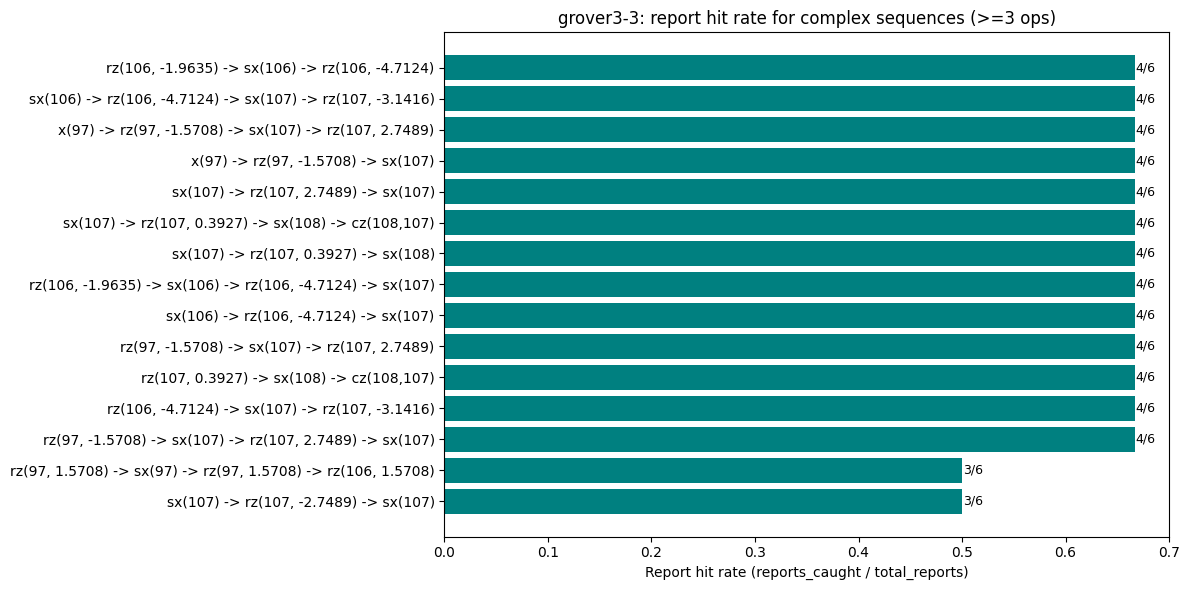

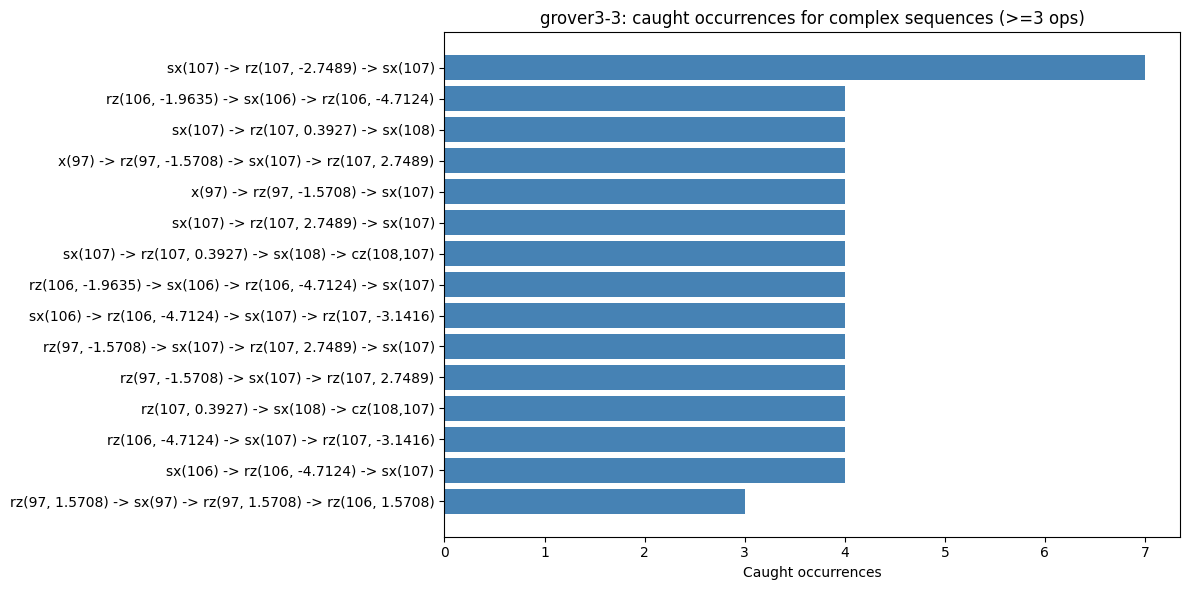

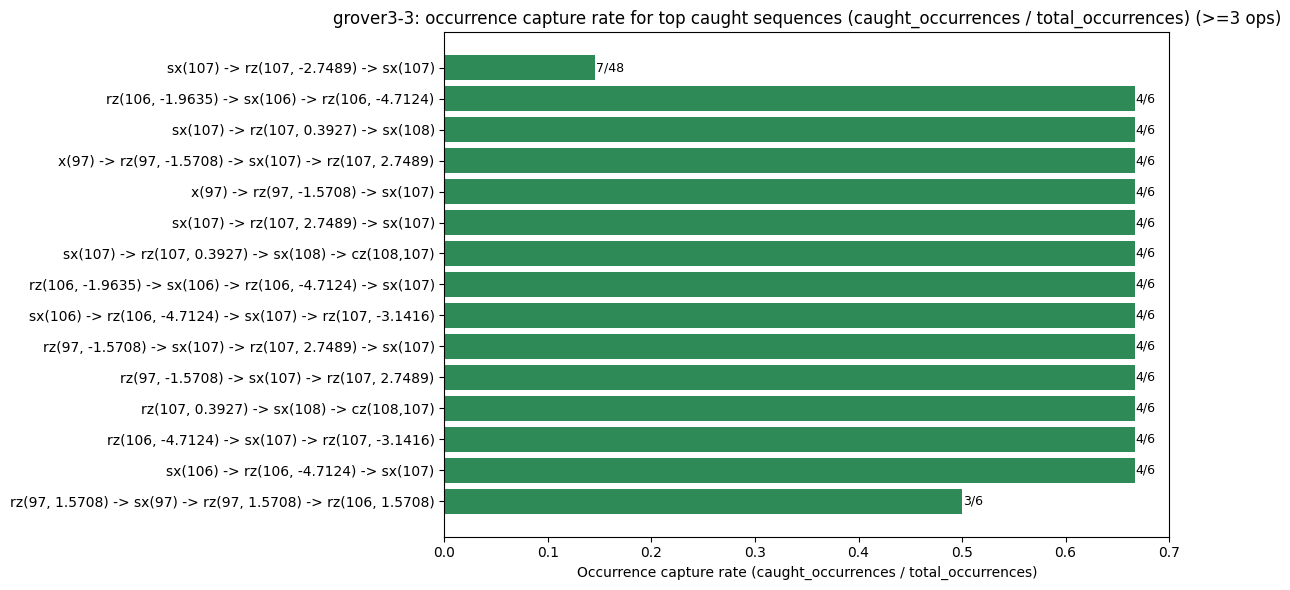


Circuit total operations (N): 154


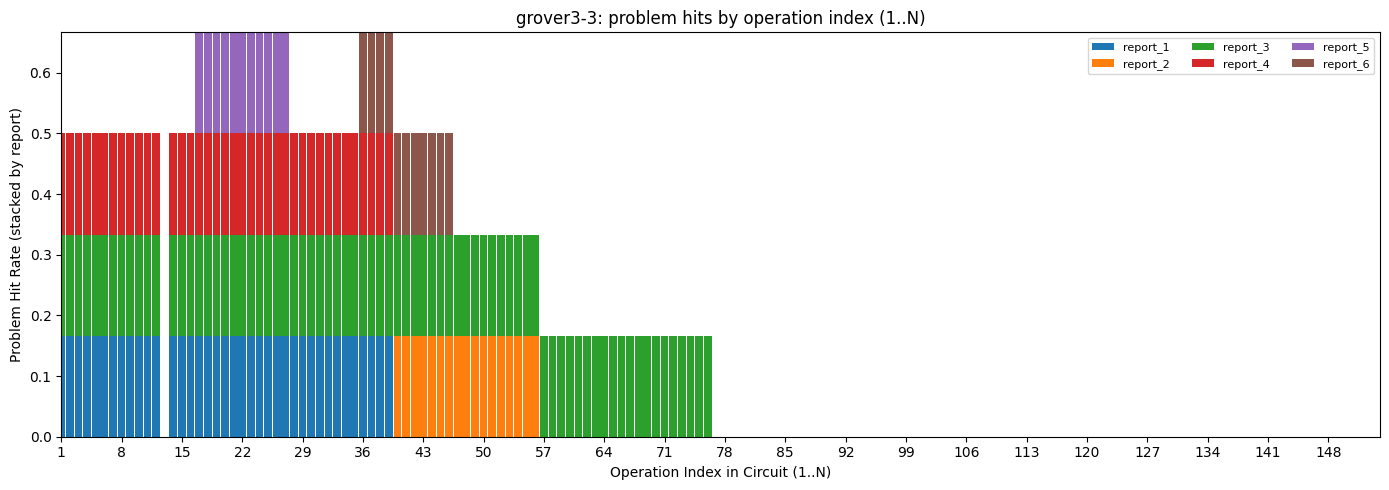

In [8]:
single_reports = load_reports(SINGLE_DIR)
total_reports = len(single_reports)
print(f"{SINGLE_DIR}: loaded reports = {total_reports}")

caught_seq_df = build_sequence_df(single_reports, SINGLE_DIR.name, source="caught")
total_seq_df = build_sequence_df(single_reports, SINGLE_DIR.name, source="total")

single_agg = aggregate_sequence_stats(caught_seq_df, total_seq_df, total_reports=total_reports)

single_agg_view = single_agg.rename(columns={
    "sequence": "Sequence (>=3 ops)",
    "caught_occurrences": "Caught Occurrences",
    "total_occurrences": "Total Occurrences in Reports",
    "occurrence_capture_rate": "Occurrence Capture Rate (caught/total)",
    "reports_caught": "Reports Caught",
    "report_hit_rate": "Report Hit Rate (reports_caught/total_reports)",
})

print("\nTop Complex Sequences (clean metrics)")
display(single_agg_view.head(20))


DEBUG_SEQUENCE = "sx(107) -> rz(107, -2.7489) -> sx(107)"
_debug = single_agg[single_agg["sequence"] == DEBUG_SEQUENCE]
print("\n[DEBUG] Third-chart numerator/denominator check")
if _debug.empty:
    print(f"Sequence not found: {DEBUG_SEQUENCE}")
else:
    r = _debug.iloc[0]
    print(f"sequence: {DEBUG_SEQUENCE}")
    print(f"caught_occurrences = {int(r['caught_occurrences'])}")
    print(f"total_occurrences  = {int(r['total_occurrences'])}")
    print(f"occurrence_capture_rate = {float(r['occurrence_capture_rate']):.6f}")
    print(f"report metric (for first chart) = {int(r['reports_caught'])}/{total_reports}")


plot_top_sequences_by_report_hit_rate(
    single_agg,
    total_reports=total_reports,
    title=f"{SINGLE_DIR.name}: report hit rate for complex sequences (>=3 ops)",
)
plot_top_sequences_by_occurrence_capture_rate(
    single_agg,
    title=f"{SINGLE_DIR.name}: occurrence capture rate for top caught sequences (caught_occurrences / total_occurrences) (>=3 ops)",
)


# New intuitive view: x=operation index in full circuit, y=problem-hit count
op_hit_df = build_operation_hit_series(single_reports, total_reports=total_reports)
if not op_hit_df.empty:
    print(f"\nCircuit total operations (N): {len(op_hit_df)}")
plot_operation_hit_series(
    op_hit_df,
    title=f"{SINGLE_DIR.name}: problem hits by operation index (1..N)",
)
